# Exploratory Data Analysis
Q-factor dataset joined with process metadata.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

CSV_PATH = 'qfactors_1.0um.csv'

## 1. Load & Overview

In [8]:
df = pd.read_csv(CSV_PATH)

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

Shape: (64977, 24)
Columns: ['filename', 'slice_id', 'position_um', 'q_factor', 'A', 'R', 'baseline', 'sigma_shoulder', 'orientation', 'inverted', 'trench_start', 'trench_end', 'pixel_size_um', 'dataset', 'sample_id', 'Material', 'Spot size(micron)', 'Power(W)', 'Scanning speed(mm/s)', 'Pass', 'Range(micron)', 'Step size(micron)', 'Sample date', 'Sample no']


,filename,slice_id,position_um,q_factor,A,R,baseline,sigma_shoulder,orientation,inverted,...,sample_id,Material,Spot size(micron),Power(W),Scanning speed(mm/s),Pass,Range(micron),Step size(micron),Sample date,Sample no
0,100_2025_08_06.tif,0,0.0,-0.092074,9.024678,9.855620,2107.4746,0.106870,horizontal,False,...,100,Silicon Wafer,15,1.85,150,1,10.4,0.8,5082025,4
1,100_2025_08_06.tif,1,1.0,-0.286394,7.600520,9.777260,2107.4731,0.113662,horizontal,False,...,100,Silicon Wafer,15,1.85,150,1,10.4,0.8,5082025,4
2,100_2025_08_06.tif,2,2.0,-1.766373,4.164368,11.520195,2107.4727,0.128401,horizontal,False,...,100,Silicon Wafer,15,1.85,150,1,10.4,0.8,5082025,4


In [9]:
df.dtypes

filename                    str
slice_id                  int64
position_um             float64
q_factor                float64
A                       float64
R                       float64
baseline                float64
sigma_shoulder          float64
orientation                 str
inverted                   bool
trench_start              int64
trench_end                int64
pixel_size_um           float64
dataset                   int64
sample_id                 int64
Material                    str
Spot size(micron)         int64
Power(W)                float64
Scanning speed(mm/s)      int64
Pass                      int64
Range(micron)           float64
Step size(micron)       float64
Sample date               int64
Sample no                 int64
dtype: object

In [10]:
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

## 2. Data Cleaning

In [11]:
# Parse sample date
df['Sample date'] = pd.to_datetime(df['Sample date'], format='%d%m%Y')

# Rename columns for convenience
df = df.rename(columns={
    'Spot size(micron)': 'spot_size',
    'Power(W)': 'power',
    'Scanning speed(mm/s)': 'scan_speed',
    'Pass': 'n_pass',
    'Range(micron)': 'range_um',
    'Step size(micron)': 'step_size',
    'Sample date': 'sample_date',
    'Sample no': 'sample_no',
    'Material': 'material',
})

meta_cols = ['material', 'spot_size', 'power', 'scan_speed', 'n_pass',
             'range_um', 'step_size', 'sample_date', 'sample_no']

print('Done.')
df[meta_cols].head(3)

Done.


,material,spot_size,power,scan_speed,n_pass,range_um,step_size,sample_date,sample_no
0,Silicon Wafer,15,1.85,150,1,10.4,0.8,2025-08-05,4
1,Silicon Wafer,15,1.85,150,1,10.4,0.8,2025-08-05,4
2,Silicon Wafer,15,1.85,150,1,10.4,0.8,2025-08-05,4


## 3. Metadata Overview

In [12]:
# Unique values for each process parameter
for col in ['material', 'spot_size', 'power', 'scan_speed', 'n_pass', 'step_size']:
    vals = df[col].unique()
    print(f'{col}: {sorted(vals)}')

material: ['Silicon Wafer']
spot_size: [np.int64(15)]
power: [np.float64(1.65), np.float64(1.85)]
scan_speed: [np.int64(10), np.int64(50), np.int64(100), np.int64(150), np.int64(200), np.int64(250), np.int64(300), np.int64(350), np.int64(400), np.int64(450), np.int64(500), np.int64(550), np.int64(600), np.int64(650), np.int64(700), np.int64(750), np.int64(800), np.int64(850), np.int64(900), np.int64(950), np.int64(1000), np.int64(1050), np.int64(1100), np.int64(1150), np.int64(1200), np.int64(1250), np.int64(1300), np.int64(1350), np.int64(1400), np.int64(1450), np.int64(1500), np.int64(1600), np.int64(1700), np.int64(1800), np.int64(1900), np.int64(2000), np.int64(2100), np.int64(2200), np.int64(2300), np.int64(2400), np.int64(2500), np.int64(2600), np.int64(2700), np.int64(2800), np.int64(2900), np.int64(3000)]
n_pass: [np.int64(1), np.int64(5), np.int64(10), np.int64(15), np.int64(20), np.int64(25), np.int64(30), np.int64(40), np.int64(50)]
step_size: [np.float64(0.8)]


In [13]:
# Samples per dataset
print('Files per dataset:')
print(df.groupby('dataset')['filename'].nunique())
print()
print('Slices per dataset:')
print(df.groupby('dataset').size())

Files per dataset:
dataset
6082025     123
26082025    300
Name: filename, dtype: int64

Slices per dataset:
dataset
6082025     18896
26082025    46081
dtype: int64


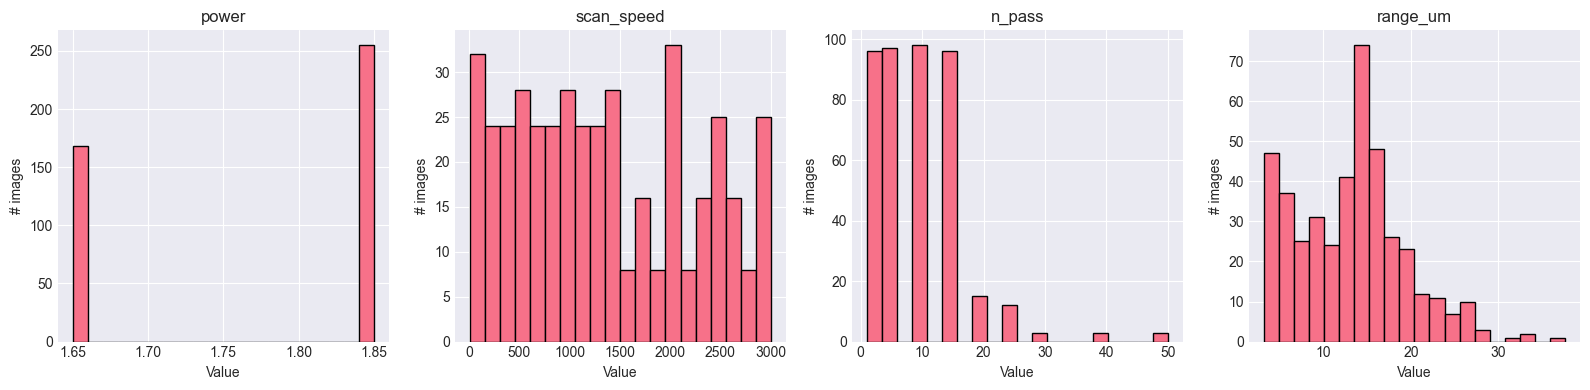

In [14]:
# Distribution of process parameters
params = ['power', 'scan_speed', 'n_pass', 'range_um']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, params):
    # Use image-level data (one row per image) to avoid slice inflation
    img_df = df.drop_duplicates('filename')
    ax.hist(img_df[col], bins=20, edgecolor='black')
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('# images')

plt.tight_layout()
plt.show()

## 4. Q-Factor Distribution

In [15]:
df_valid = df[df['q_factor'].notna() & df['q_factor'].between(0, 1)]

print(f'Total slices    : {len(df):,}')
print(f'Valid Q slices  : {len(df_valid):,} ({len(df_valid)/len(df)*100:.1f}%)')
print()
print(df_valid['q_factor'].describe().round(4))

Total slices    : 64,977
Valid Q slices  : 62,772 (96.6%)

count    62772.0000
mean         0.8507
std          0.1817
min          0.0005
25%          0.7982
50%          0.9151
75%          0.9765
max          1.0000
Name: q_factor, dtype: float64


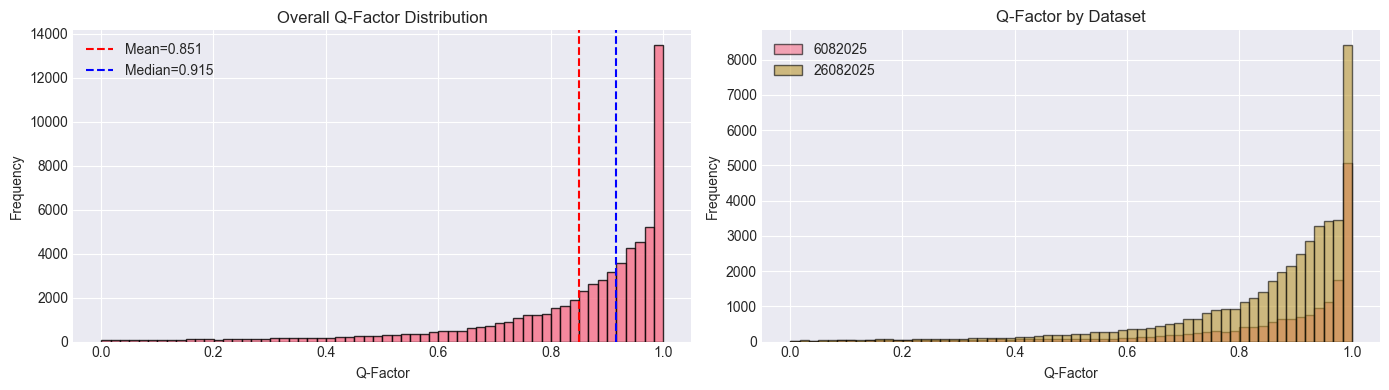

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Overall distribution
axes[0].hist(df_valid['q_factor'], bins=60, edgecolor='black', alpha=0.8)
axes[0].axvline(df_valid['q_factor'].mean(), color='red', linestyle='--', label=f'Mean={df_valid["q_factor"].mean():.3f}')
axes[0].axvline(df_valid['q_factor'].median(), color='blue', linestyle='--', label=f'Median={df_valid["q_factor"].median():.3f}')
axes[0].set_xlabel('Q-Factor')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Overall Q-Factor Distribution')
axes[0].legend()

# Per dataset
for dataset, grp in df_valid.groupby('dataset'):
    axes[1].hist(grp['q_factor'], bins=60, alpha=0.6, label=dataset, edgecolor='black')
axes[1].set_xlabel('Q-Factor')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Q-Factor by Dataset')
axes[1].legend()

plt.tight_layout()
plt.show()

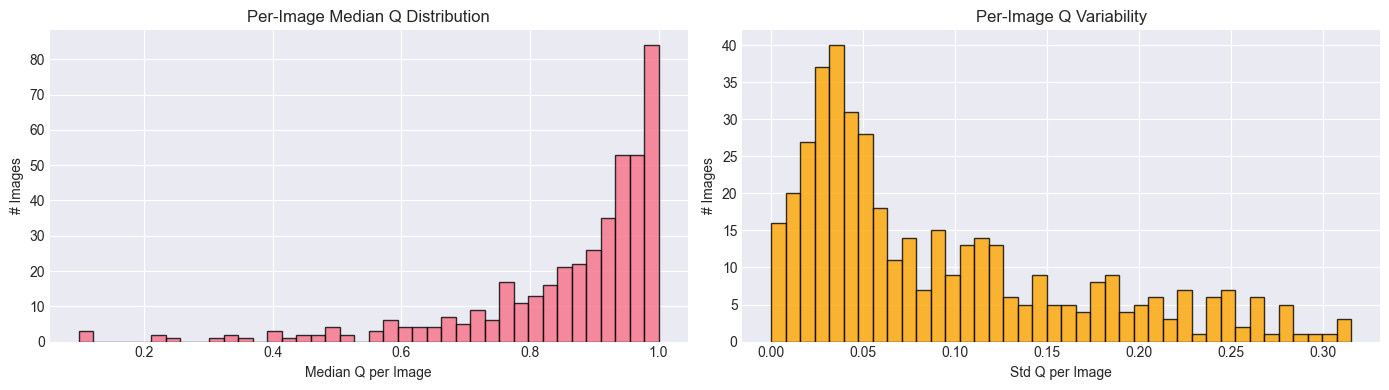

In [17]:
# Per-image Q stats
img_q = df_valid.groupby('filename')['q_factor'].agg(
    q_median='median', q_mean='mean', q_std='std', n_slices='count'
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(img_q['q_median'], bins=40, edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Median Q per Image')
axes[0].set_ylabel('# Images')
axes[0].set_title('Per-Image Median Q Distribution')

axes[1].hist(img_q['q_std'], bins=40, edgecolor='black', alpha=0.8, color='orange')
axes[1].set_xlabel('Std Q per Image')
axes[1].set_ylabel('# Images')
axes[1].set_title('Per-Image Q Variability')

plt.tight_layout()
plt.show()

## 5. Q vs Process Parameters

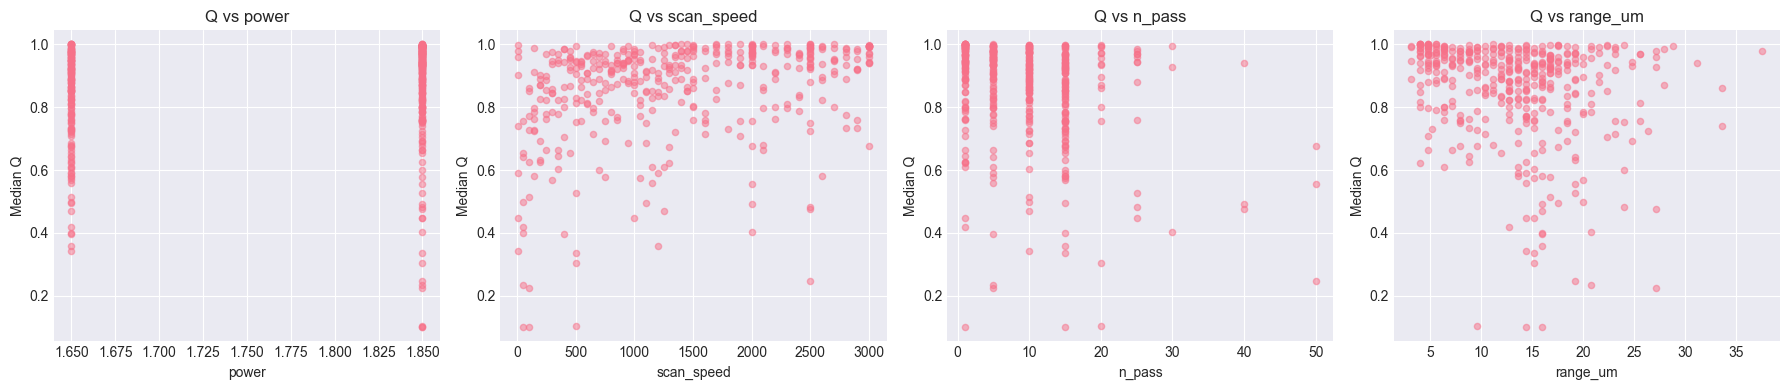

In [18]:
# Use per-image median Q joined back with metadata
img_meta = df_valid.drop_duplicates('filename')[['filename', 'power', 'scan_speed', 'n_pass', 'range_um', 'step_size', 'spot_size', 'dataset']]
img_q_meta = img_q.merge(img_meta, on='filename')

params = ['power', 'scan_speed', 'n_pass', 'range_um']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, col in zip(axes, params):
    ax.scatter(img_q_meta[col], img_q_meta['q_median'], alpha=0.5, s=20)
    ax.set_xlabel(col)
    ax.set_ylabel('Median Q')
    ax.set_title(f'Q vs {col}')

plt.tight_layout()
plt.show()

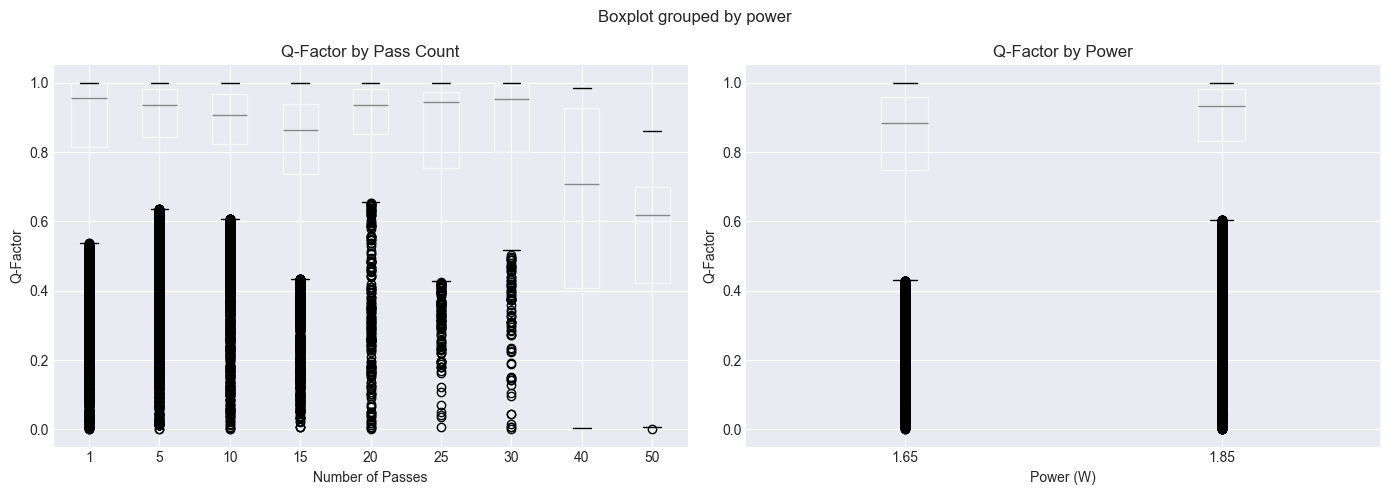

In [19]:
# Box plots — Q distribution per n_pass and per power level
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pass_order = sorted(df_valid['n_pass'].unique())
df_valid.boxplot(column='q_factor', by='n_pass', ax=axes[0], positions=range(len(pass_order)))
axes[0].set_xticklabels(pass_order)
axes[0].set_xlabel('Number of Passes')
axes[0].set_ylabel('Q-Factor')
axes[0].set_title('Q-Factor by Pass Count')
plt.sca(axes[0])
plt.title('Q-Factor by Pass Count')

power_order = sorted(df_valid['power'].unique())
df_valid.boxplot(column='q_factor', by='power', ax=axes[1])
axes[1].set_xlabel('Power (W)')
axes[1].set_ylabel('Q-Factor')
plt.sca(axes[1])
plt.title('Q-Factor by Power')

plt.tight_layout()
plt.show()

## 6. Correlation Analysis

Dropped constant columns: {'spot_size', 'step_size'}


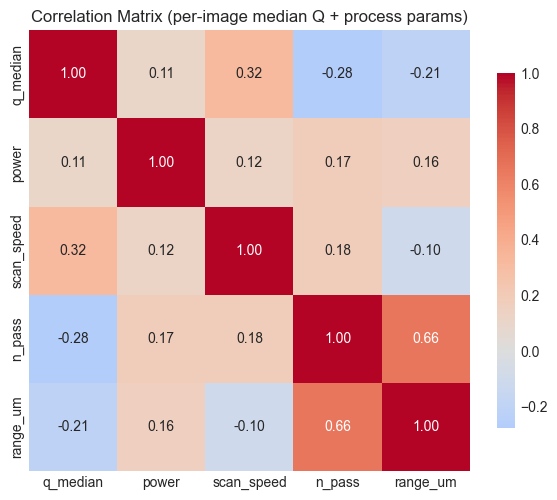

In [23]:
corr_cols = ['q_median', 'power', 'scan_speed', 'n_pass', 'range_um', 'step_size', 'spot_size']

# Drop constant columns (zero variance — correlation undefined)
varying = [c for c in corr_cols if img_q_meta[c].nunique() > 1]
dropped = set(corr_cols) - set(varying)
if dropped:
    print(f"Dropped constant columns: {dropped}")

corr = img_q_meta[varying].corr()

fig, ax = plt.subplots(figsize=(len(varying) * 1.2, len(varying)))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix (per-image median Q + process params)')
plt.tight_layout()
plt.show()

In [ ]:
print('Correlation with q_median:')
print(corr['q_median'].drop('q_median').sort_values(key=abs, ascending=False).round(3))

## 7. A & R Analysis

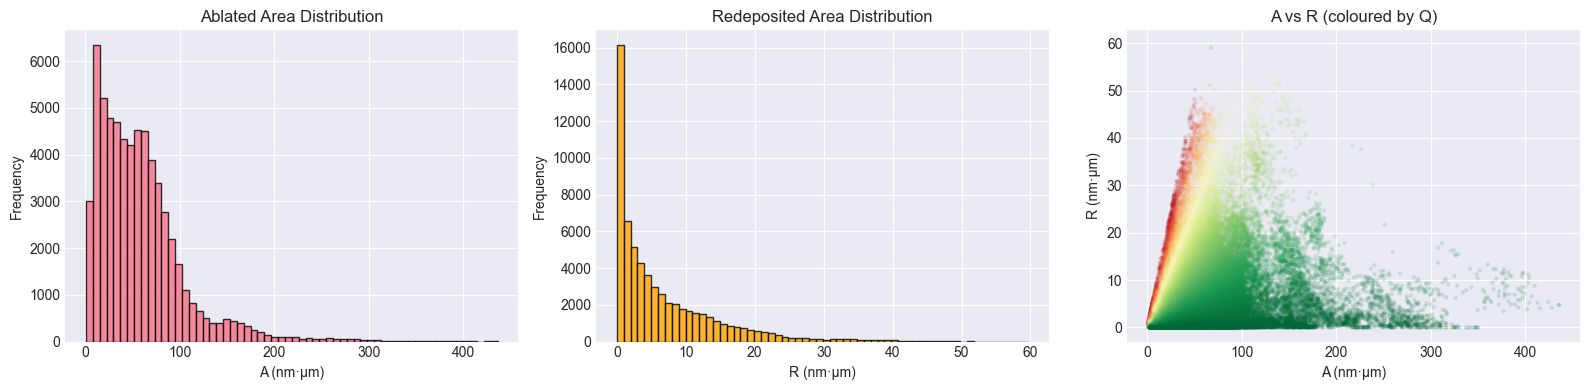

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df_valid['A'], bins=60, edgecolor='black', alpha=0.8)
axes[0].set_xlabel('A (nm·µm)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Ablated Area Distribution')

axes[1].hist(df_valid['R'], bins=60, edgecolor='black', alpha=0.8, color='orange')
axes[1].set_xlabel('R (nm·µm)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Redeposited Area Distribution')

axes[2].scatter(df_valid['A'], df_valid['R'], alpha=0.1, s=5, c=df_valid['q_factor'], cmap='RdYlGn')
axes[2].set_xlabel('A (nm·µm)')
axes[2].set_ylabel('R (nm·µm)')
axes[2].set_title('A vs R (coloured by Q)')

plt.tight_layout()
plt.show()